# Function 8 Analysis - Week 11

1. **Function description (unchanged):**  
You're optimising an eight-dimensional black-box function; each parameter influences the output (e.g., performance/accuracy), but the mechanism is unknown. The goal is to maximise the response, so we rely on BO to navigate a likely multi-modal surface while prioritising strong local maxima.

2. **Week 10 evaluated point:** `(0.049871, 0.052069, 0.031726, 0.051612, 0.580269, 0.958319, 0.200177, 0.689827)` returned **≈9.7117**, so it is a good point but **not a new maximum**.

3. **Analysis of last point:** The high score reinforces the plateau view near the incumbent basin, but this move did not exceed the best known value.

4. **Why we chose last week’s point (from Week 10 logic):** Week 10 assumed a high-value plateau and selected a TuRBO-style trust-region EI step around the incumbent basin to stay in the most promising local region.

5. **Recommendation for Week 12 (and why):** Keep trust-region EI, recenter slightly toward the incumbent best coordinate profile, and use a small perturbation move. 


## Loading and Displaying the Data

We load the inputs and outputs for function 8. Week 10 `(0.049871, 0.052069, 0.031726, 0.051612, 0.580269, 0.958319, 0.200177, 0.689827)` returned **≈9.7117** and has been added to the dataset.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_8")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Add the new points from Week 1–8
X_new_point_week_1 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.250000, 0.450000]])
y_new_point_week_1 = np.array([9.74365])
X_new_point_week_2 = np.array([[0.100000, 0.100000, 0.100000, 0.100000, 0.100000, 0.400000, 0.250000, 0.450000]])
y_new_point_week_2 = np.array([9.73005])
X_new_point_week_3 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.000000, 1.000000]])
y_new_point_week_3 = np.array([9.6549])
X_new_point_week_4 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.100000, 0.350000]])
y_new_point_week_4 = np.array([9.72465])
X_new_point_week_5 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.210300, 0.700000]])
y_new_point_week_5 = np.array([9.74968782])
X_new_point_week_6 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.306800, 0.700000]])
y_new_point_week_6 = np.array([9.72708752])
X_new_point_week_7 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.220000, 0.710000]])
y_new_point_week_7 = np.array([9.74889])
X_new_point_week_8 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.601973, 0.930000, 0.190000, 0.680000]])
y_new_point_week_8 = np.array([9.7504526536355])
X_new_point_week_9 = np.array([[0.047376, 0.055987, 0.028756, 0.041164, 0.589975, 0.923480, 0.229032, 0.665521]])
y_new_point_week_9 = np.array([9.7395210926704])
X_new_point_week_10 = np.array([[0.049871, 0.052069, 0.031726, 0.051612, 0.580269, 0.958319, 0.200177, 0.689827]])
y_new_point_week_10 = np.array([9.7117260365926])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
    X_new_point_week_10,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
    y_new_point_week_10,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


df sorted by y


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.050000,0.050000,0.050000,0.050000,0.601973,0.930000,0.190000,0.680000,9.750453
1,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.210300,0.700000,9.749688
2,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.220000,0.710000,9.748890
3,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.250000,0.450000,9.743650
4,0.047376,0.055987,0.028756,0.041164,0.589975,0.923480,0.229032,0.665521,9.739521
5,0.100000,0.100000,0.100000,0.100000,0.100000,0.400000,0.250000,0.450000,9.730050
6,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.306800,0.700000,9.727088
7,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.100000,0.350000,9.724650
8,0.049871,0.052069,0.031726,0.051612,0.580269,0.958319,0.200177,0.689827,9.711726
9,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.000000,1.000000,9.654900


## Weekly Optimization Progress Summary

Overview of all 10 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

- **Week 10 update:** `(0.049871, 0.052069, 0.031726, 0.051612, 0.580269, 0.958319, 0.200177, 0.689827)` → **≈9.7117** (not a new maximum).


In [2]:
# Build weekly progress dataframe from available week variables (auto-detect)
weekly_X, weekly_y = [], []
week_idx = 1
while f'X_new_point_week_{week_idx}' in globals() and f'y_new_point_week_{week_idx}' in globals():
    weekly_X.append(globals()[f'X_new_point_week_{week_idx}'])
    weekly_y.append(globals()[f'y_new_point_week_{week_idx}'])
    week_idx += 1

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'x5': [x[0, 4] for x in weekly_X],
    'x6': [x[0, 5] for x in weekly_X],
    'x7': [x[0, 6] for x in weekly_X],
    'x8': [x[0, 7] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print('=' * 150)
print('WEEKLY OPTIMIZATION PROGRESS')
print('=' * 150)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f'+{x:.6f}' if pd.notna(x) else '-')
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,x5,x6,x7,x8,y,Running_Max,Status,Improvement
0,1,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.250000,0.450000,9.743650,9.743650,✓ NEW MAX,+9.743650
1,2,0.100000,0.100000,0.100000,0.100000,0.100000,0.400000,0.250000,0.450000,9.730050,9.743650,✗,-
2,3,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.000000,1.000000,9.654900,9.743650,✗,-
3,4,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.100000,0.350000,9.724650,9.743650,✗,-
4,5,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.210300,0.700000,9.749688,9.749688,✓ NEW MAX,+0.006038
5,6,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.306800,0.700000,9.727088,9.749688,✗,-
6,7,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.220000,0.710000,9.748890,9.749688,✗,-
7,8,0.050000,0.050000,0.050000,0.050000,0.601973,0.930000,0.190000,0.680000,9.750453,9.750453,✓ NEW MAX,+0.000765
8,9,0.047376,0.055987,0.028756,0.041164,0.589975,0.923480,0.229032,0.665521,9.739521,9.750453,✗,-
9,10,0.049871,0.052069,0.031726,0.051612,0.580269,0.958319,0.200177,0.689827,9.711726,9.750453,✗,-



📊 Summary: 3/10 weeks achieved new max (Weeks [1, 5, 8])
   Success rate: 30.0% | Final best: 9.750453


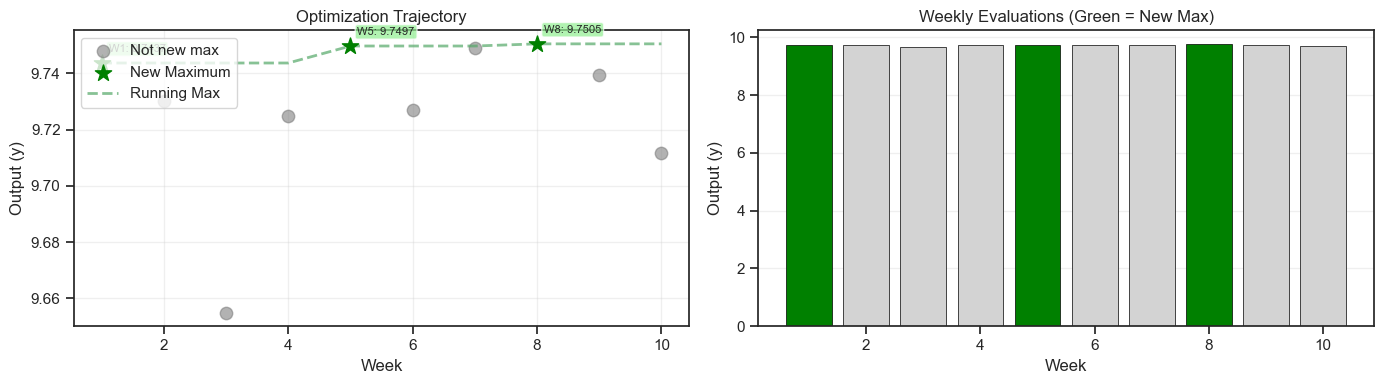

In [3]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.50427387 2.13100433 1.09310273 3.50120412 5.         2.56347148
 1.60199548 5.        ]
Full kernel parameters: {'length_scale': array([1.50427387, 2.13100433, 1.09310273, 3.50120412, 5.        ,
       2.56347148, 1.60199548, 5.        ]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 4 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Random Forest Analysis: Feature Importance Check

We've been assuming x7 and x8 are the key levers while fixing x1-x4 at 0.05. Let's verify this with a Random Forest to see if we're missing anything.


RANDOM FOREST FEATURE IMPORTANCE
x1: 0.547 ###########################
x3: 0.254 ############
x7: 0.069 ###
x2: 0.050 ##
x4: 0.031 #
x5: 0.022 #
x6: 0.014 
x8: 0.012 


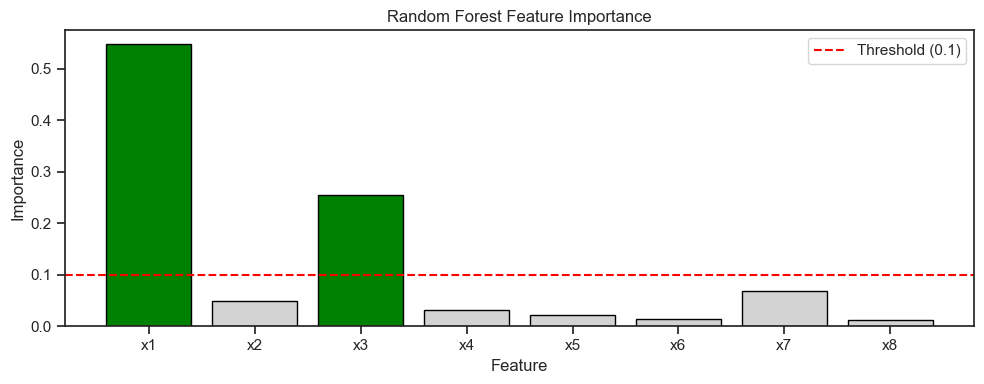


RF-BASED GRID SEARCH

Top 5 RF candidates:
      x1       x2       x3       x4       x5       x6       x7       x8  rf_pred  rf_sigma      ucb
0.050251 0.031092 0.056670 0.047503 0.617730 0.917375 0.207720 0.627907 9.734018  0.067138 9.740732
0.080454 0.005703 0.059418 0.045890 0.597832 0.923384 0.217465 0.650126 9.726681  0.140110 9.740692
0.073973 0.029577 0.054766 0.026985 0.600892 0.907176 0.219992 0.645052 9.732988  0.067810 9.739769
0.049567 0.045598 0.055746 0.034897 0.634283 0.937656 0.223870 0.647865 9.733827  0.054019 9.739229
0.071136 0.031462 0.048784 0.043213 0.600521 0.918739 0.206861 0.629856 9.731847  0.068076 9.738655

RF RECOMMENDATION
x1=0.050251, x2=0.031092, x3=0.056670, x4=0.047503
x5=0.617730, x6=0.917375, x7=0.207720, x8=0.627907
RF prediction: 9.7340 +/- 0.0671

RF SUBMISSION FORMAT
0.050251-0.031092-0.056670-0.047503-0.617730-0.917375-0.207720-0.627907


In [5]:
from sklearn.ensemble import RandomForestRegressor

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Feature importance
feature_names = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']
importances = rf.feature_importances_

print('='*60)
print('RANDOM FOREST FEATURE IMPORTANCE')
print('='*60)
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    bar = '#' * int(imp * 50)
    print(f'{name}: {imp:.3f} {bar}')

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if imp > 0.1 else 'lightgray' for imp in importances]
ax.bar(feature_names, importances, color=colors, edgecolor='black')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.set_title('Random Forest Feature Importance')
ax.axhline(y=0.1, color='red', linestyle='--', label='Threshold (0.1)')
ax.legend()
plt.tight_layout()
plt.show()

# RF-based grid search for best point
print('\n' + '='*60)
print('RF-BASED GRID SEARCH')
print('='*60)

# Search bounds - use wider bounds for RF to check if we're missing something
rf_bounds = [
    (0.0, 0.15),   # x1 - test if 0.05 is really best
    (0.0, 0.15),   # x2
    (0.0, 0.15),   # x3
    (0.0, 0.15),   # x4
    (0.55, 0.65),  # x5
    (0.90, 0.96),  # x6
    (0.15, 0.25),  # x7 (around winning value)
    (0.62, 0.74),  # x8 (around winning value)
]

# Generate mesh
n_samples = 50000
np.random.seed(42)
mesh = np.array([[np.random.uniform(lo, hi) for lo, hi in rf_bounds] for _ in range(n_samples)])

# Get RF predictions and uncertainty (via tree disagreement)
rf_preds = rf.predict(mesh)
tree_preds = np.array([tree.predict(mesh) for tree in rf.estimators_])
rf_sigma = tree_preds.std(axis=0)

# UCB with exploration
beta = 0.1  # light exploration
rf_ucb = rf_preds + beta * rf_sigma

# Find top candidates
candidates = pd.DataFrame(mesh, columns=feature_names)
candidates['rf_pred'] = rf_preds
candidates['rf_sigma'] = rf_sigma
candidates['ucb'] = rf_ucb

# Distance filter
def min_dist(row):
    pt = row[feature_names].values
    return np.sqrt(((X - pt)**2).sum(axis=1)).min()

candidates['min_dist'] = candidates.apply(min_dist, axis=1)
candidates_filtered = candidates[candidates['min_dist'] > 0.02].copy()

if len(candidates_filtered) > 0:
    rf_top = candidates_filtered.nlargest(5, 'ucb')
else:
    rf_top = candidates.nlargest(5, 'ucb')

print('\nTop 5 RF candidates:')
print(rf_top[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'rf_pred', 'rf_sigma', 'ucb']].to_string(index=False))

if len(rf_top) > 0:
    rf_rec = rf_top.iloc[0]
    print(f'\n' + '='*60)
    print('RF RECOMMENDATION')
    print('='*60)
    print(f'x1={rf_rec["x1"]:.6f}, x2={rf_rec["x2"]:.6f}, x3={rf_rec["x3"]:.6f}, x4={rf_rec["x4"]:.6f}')
    print(f'x5={rf_rec["x5"]:.6f}, x6={rf_rec["x6"]:.6f}, x7={rf_rec["x7"]:.6f}, x8={rf_rec["x8"]:.6f}')
    print(f'RF prediction: {rf_rec["rf_pred"]:.4f} +/- {rf_rec["rf_sigma"]:.4f}')
    
    print(f'\n' + '='*60)
    print('RF SUBMISSION FORMAT')
    print('='*60)
    print(f'{rf_rec["x1"]:.6f}-{rf_rec["x2"]:.6f}-{rf_rec["x3"]:.6f}-{rf_rec["x4"]:.6f}-{rf_rec["x5"]:.6f}-{rf_rec["x6"]:.6f}-{rf_rec["x7"]:.6f}-{rf_rec["x8"]:.6f}')


## Finding the Next Point to Evaluate (relaxed TuRBO-EI search)

Given the broader plateau behavior, we relax the local trust-region constraints to allow more exploratory movement while still staying anchored near the incumbent basin. Inside this wider region, we maximize EI and keep a minimum-distance filter to avoid re-testing near-duplicates.


In [6]:
from scipy.stats import norm

# TuRBO-style local trust region + EI
rng = np.random.default_rng(42)

# Current best point
y_best = y.max()
best_idx = y.argmax()
best_point = X[best_idx].copy()

print(f"Current best score: {y_best:.6f}")
print(f"Current best point: {best_point}")

# Relaxed trust region centered at incumbent (plateau seems broad)
trust_radius = np.array([0.06, 0.06, 0.06, 0.06, 0.07, 0.06, 0.07, 0.08])
lb = np.maximum(0.0, best_point - trust_radius)
ub = np.minimum(1.0, best_point + trust_radius)

print("\nTuRBO trust region bounds:")
for i in range(8):
    print(f"  x{i+1}: [{lb[i]:.4f}, {ub[i]:.4f}]")

# Sample candidates in trust region
n_cand = 60000
cand = rng.uniform(lb, ub, size=(n_cand, 8))

# EI acquisition in trust region (slightly more exploratory xi)
xi = 0.03
mu, sigma = gp.predict(cand, return_std=True)
sigma_safe = np.maximum(sigma, 1e-9)
improvement = mu - y_best - xi
z = improvement / sigma_safe
ei = improvement * norm.cdf(z) + sigma_safe * norm.pdf(z)
ei[sigma <= 1e-9] = 0.0

# Distance filter to avoid replaying old points
dist = np.sqrt(((cand[:, None, :] - X[None, :, :])**2).sum(axis=2))
min_dist = dist.min(axis=1)
mask = min_dist >= 0.01
cand = cand[mask]
mu = mu[mask]
sigma = sigma[mask]
ei = ei[mask]

# Best EI in trust region
idx = np.argmax(ei)
next_point = cand[idx]
mu_pred = np.array([mu[idx]])
sigma_pred = np.array([sigma[idx]])

print(f"\n{'='*60}")
print("TURBO-EI RECOMMENDATION")
print(f"{'='*60}")
print("\nNext point to evaluate:")
print(f"  x1={next_point[0]:.6f}, x2={next_point[1]:.6f}, x3={next_point[2]:.6f}, x4={next_point[3]:.6f}")
print(f"  x5={next_point[4]:.6f}, x6={next_point[5]:.6f}, x7={next_point[6]:.6f}, x8={next_point[7]:.6f}")
print(f"\nPredicted output: {mu_pred[0]:.4f} +/- {sigma_pred[0]:.4f}")
print(f"Expected Improvement: {ei[idx]:.6f}")

print(f"\n{'='*60}")
print("TURBO-EI SUBMISSION FORMAT")
print(f"{'='*60}")
print(f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}-{next_point[4]:.6f}-{next_point[5]:.6f}-{next_point[6]:.6f}-{next_point[7]:.6f}")



Current best score: 9.750453
Current best point: [0.05     0.05     0.05     0.05     0.601973 0.93     0.19     0.68    ]

TuRBO trust region bounds:
  x1: [0.0000, 0.1100]
  x2: [0.0000, 0.1100]
  x3: [0.0000, 0.1100]
  x4: [0.0000, 0.1100]
  x5: [0.5320, 0.6720]
  x6: [0.8700, 0.9900]
  x7: [0.1200, 0.2600]
  x8: [0.6000, 0.7600]



TURBO-EI RECOMMENDATION

Next point to evaluate:
  x1=0.055183, x2=0.076360, x3=0.108773, x4=0.013492
  x5=0.664084, x6=0.878584, x7=0.184722, x8=0.686112

Predicted output: 9.8439 +/- 0.0198
Expected Improvement: 0.063465

TURBO-EI SUBMISSION FORMAT
0.055183-0.076360-0.108773-0.013492-0.664084-0.878584-0.184722-0.686112


## Distance Analysis of Recommended Point

We calculate the Euclidean distance from the recommended point to all existing observations. This helps us understand how similar the recommended point is to our existing data. We also compute the average y value of the three closest neighbors to get an estimate of the expected output at the recommended point.


In [7]:
distances = np.sqrt(((X - next_point)**2).sum(axis=1))
df_dist = pd.DataFrame({"point_index": range(len(X)), "distance": distances, "y": y})
df_dist = df_dist.sort_values("distance")
print("Euclidean distances from recommended point to all observations:")
print(df_dist.to_string(index=False))
closest_3 = df_dist.head(3)
avg_y = closest_3["y"].mean()
print(f"\nThree closest neighbors: points {closest_3['point_index'].tolist()}")
print(f"Average y value of closest 3 neighbors: {avg_y:.4f}")


Euclidean distances from recommended point to all observations:
 point_index  distance        y
          47  0.109889 9.750453
          44  0.114483 9.749688
          46  0.118636 9.748890
          48  0.132438 9.739521
          49  0.147116 9.711726
          45  0.165394 9.727088
          40  0.268830 9.743650
          43  0.363880 9.724650
          42  0.380666 9.654900
          14  0.465627 9.598482
          22  0.783606 9.141639
          41  0.785730 9.730050
          26  0.936565 9.344274
          31  1.033049 8.421759
          32  1.049699 8.278062
           5  1.055356 8.541748
          23  1.066293 8.817558
          39  1.101029 9.183005
          30  1.149434 7.923759
          35  1.165232 8.472936
          12  1.189045 8.976554
           0  1.195503 7.398721
          25  1.197810 8.830745
           4  1.246135 8.606117
          28  1.264117 8.042213
          38  1.273159 7.436594
          18  1.278364 7.433744
          15  1.281467 8.159983
        

**Current best:** `0.050000-0.050000-0.050000-0.050000-0.602000-0.930000-0.190000-0.680000` (≈9.7505)

**Week 10 evaluated point:** `0.049871-0.052069-0.031726-0.051612-0.580269-0.958319-0.200177-0.689827` → ≈9.7117 (high, but not a new maximum).

**Proposed next point (submission format):** use the relaxed TuRBO-EI output printed above.

Because the plateau appears broad, we deliberately widened the trust region and increased exploration pressure (`xi`) to test farther local alternatives while still staying around the incumbent basin.


In [ ]:
# ============================================================
# FINAL DECISION: TuRBO-EI local trust region
# ============================================================

print('='*70)
print('FINAL DECISION: TuRBO-style trust region + EI')
print('='*70)

# Final point = TuRBO-EI recommendation from cell above
final_point = np.array(next_point)
final_gp_mu = gp.predict(final_point.reshape(1, -1))[0]
final_rf_mu = rf.predict(final_point.reshape(1, -1))[0]

print('\nRationale:')
print('  1. We are on a plateau, suggesting local smoothness with limited noise.')
print('  2. TuRBO keeps search in a safe local trust region around incumbent.')
print('  3. EI selects the best local improvement candidate inside that region.')

print('\nModel cross-check at chosen point:')
print(f'  GP prediction: {final_gp_mu:.4f}')
print(f'  RF prediction: {final_rf_mu:.4f}')

print('\n' + '='*70)
print('FINAL SUBMISSION FORMAT (TURBO-EI)')
print('='*70)
print(f'\n{final_point[0]:.6f}-{final_point[1]:.6f}-{final_point[2]:.6f}-{final_point[3]:.6f}-{final_point[4]:.6f}-{final_point[5]:.6f}-{final_point[6]:.6f}-{final_point[7]:.6f}')
print('\n' + '='*70)



FINAL DECISION: TuRBO-style trust region + EI

Rationale:
  1. We are on a plateau, suggesting local smoothness with limited noise.
  2. TuRBO keeps search in a safe local trust region around incumbent.
  3. EI selects the best local improvement candidate inside that region.

Model cross-check at chosen point:
  GP prediction: 9.8439
  RF prediction: 9.6643

FINAL SUBMISSION FORMAT (TURBO-EI)

0.055183-0.076360-0.108773-0.013492-0.664084-0.878584-0.184722-0.686112



: 